# Analysis of Task 4 

We will recreate the analysis we did in `analysis-t4.qmd`. 

Recall that Task 4 is the task where we ask the participant to find the highest sloped on the CDF (i.e., find mode on CDF). 

We ran the following models: 

- The Exponential model 
- The Lomax model  
- The Weibull model (this is also the best-performing model from LOO model comparison). 
- The Log-Normal model

Finally we compared all models in @sec-model-compare. 

In [44]:
import polars as pl
import pandas as pd
import pymc as pm
import arviz as az
import arviz_plots as azp

In [2]:
# read in data 
task4_df = pl.read_csv("../data/processed/task4.csv")
task4_df

participantId,task,id,rsp_time,status,data.select.x,data.select.y,pixel.select.x,pixel.select.y,param.mu,param.sigma,param.lambda,param.p,param.q,data.select.slope,data.ans.slope,pixelToMM,dist_to_screen,phy.select.x,phy.select.y,va.select.x,va.select.y,data.ans.x,data.ans.y,pixel.ans.x,pixel.ans.y,phy.ans.x,phy.ans.y,va.ans.x,va.ans.y
str,str,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""67f03733938aa3f0d17ce8a8""","""task4""",1,6.34,"""completed""",1.01,0.634547,371.535,159.353986,-0.05,0.94,0.5,3.79,3.59,0.343883,0.367885,4.6,668.258963,69.898913,54.488264,5.9876,4.669177,-0.05,0.25,314.825,311.25,57.570652,21.467391,4.932994,1.840432
"""67f03733938aa3f0d17ce8a8""","""task4""",2,5.652,"""completed""",-0.36,0.704049,298.24,131.900779,-1.23,1.12,0.11,3.23,19.54,0.283315,0.302315,4.6,668.258963,53.965217,60.456352,4.624406,5.179929,-1.23,0.445,251.695,234.225,43.846739,38.211957,3.758023,3.275358
"""67f03733938aa3f0d17ce8a8""","""task4""",3,4.847,"""completed""",1.72,0.516156,409.52,206.118235,1.38,0.76,0.31,2.3,21.45,0.490693,0.508989,4.6,668.258963,78.156522,44.322123,6.69343,3.798737,1.38,0.345,391.33,273.725,74.202174,29.625,6.355487,2.539599
"""67f03733938aa3f0d17ce8a8""","""task4""",4,5.566,"""completed""",-0.55,0.635886,288.075,158.825113,-0.61,0.62,-0.21,4.44,9.3,0.51476,0.514764,4.6,668.258963,51.755435,54.603236,4.435237,4.679019,-0.61,0.605,284.865,171.025,51.057609,51.951087,4.375495,4.451987
"""67f03733938aa3f0d17ce8a8""","""task4""",5,4.291,"""completed""",0.41,0.582029,339.435,180.09862,0.67,1.25,-0.33,2.12,43.26,0.317045,0.320102,4.6,668.258963,62.920652,49.978561,5.390766,4.28311,0.67,0.665,353.345,147.325,65.944565,57.103261,5.649432,4.892994
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""67ee2686d7cfcbbd9d87dd04""","""task4""",6,165.918,"""completed""",-0.74,0.137097,277.91,355.846488,-0.34,0.85,0.41,3.35,13.09,0.366305,0.403501,4.482353,587.915846,50.846063,12.081492,4.952156,1.177369,-0.34,0.295,299.31,293.475,55.620341,25.996391,5.416485,2.533085
"""67ee2686d7cfcbbd9d87dd04""","""task4""",7,166.334,"""completed""",-1.17,0.147631,254.905,351.685851,0.82,1.62,-0.06,3.59,30.61,0.155932,0.203024,4.482353,587.915846,45.713714,13.009718,4.452822,1.26782,0.82,0.53,361.37,200.65,69.465748,46.705381,6.761977,4.549316
"""67ee2686d7cfcbbd9d87dd04""","""task4""",8,53.856,"""completed""",0.97,0.80484,369.395,92.08802,1.06,0.55,-0.72,4.11,10.07,0.612879,0.612885,4.482353,587.915846,71.256102,70.925245,6.935835,6.903708,1.06,0.86,374.21,70.3,72.330315,75.786089,7.040134,7.375588


## Exponential Model 

The following is the math model: 

$$
\begin{align}
\text{error\_i} &\sim \text{Exponential}(\lambda_{\text{PID}[i]}) \\ 
\log(\lambda_j) &\sim \mathcal{N}(\mu_\lambda, \sigma_\lambda) \\ 
\mu_\lambda &\sim \mathcal{N}(0, 1) \\ 
\sigma_\lambda &\sim \text{Half-Cauchy}(0, 1) 
\end{align}
$$

In [19]:
# prepare data 
def data_to_screen_slope(k):
    return k * 395 / 53.5

obv_error = abs((data_to_screen_slope(task4_df.select("data.select.slope")) - data_to_screen_slope(task4_df.select("data.ans.slope"))).to_numpy().flatten())

In [5]:
participant_ids = task4_df.select("participantId").to_numpy().flatten()
participant_idx, unq_pids = pd.factorize(participant_ids)

In [28]:
with pm.Model(coords = {
    "participant": unq_pids
}) as task4_exp:
    # hyperprior 
    sigma_lambda = pm.HalfCauchy("sigma_lambda", 1)
    mu_lambda = pm.Normal("mu_lambda", 0, 1)
    # parameter 
    log_lambda = pm.Normal("log_lambda", mu_lambda, sigma_lambda, dims = "participant")
    p_lambda = pm.math.exp(log_lambda[participant_idx])

    # likelihood 
    error = pm.Exponential("error", p_lambda, observed=obv_error)

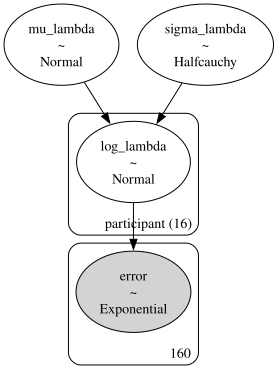

In [29]:
pm.model_to_graphviz(task4_exp)

In [30]:
# fit 
with task4_exp:
    task4_exp_idata = pm.sample(
        draws=3000,
        tune=3000,
        chains=4,
        cores=4,
        # target_accept=0.95,
        random_seed = 42, 
        progressbar=False
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_lambda, mu_lambda, log_lambda]
Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 1 seconds.


In [32]:
az.summary(task4_exp_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_lambda,1.873,0.400,1.104,2.602,0.003,0.004,18589.0,8737.0,1.0
log_lambda[67f03733938aa3f0d17ce8a8],2.443,0.324,1.837,3.037,0.002,0.003,23330.0,9039.0,1.0
log_lambda[5c8f2ac8d7ecab0018d529aa],-0.368,0.307,-0.937,0.208,0.002,0.003,24799.0,9268.0,1.0
log_lambda[6740e1e09ca406ab781318cb],1.919,0.315,1.323,2.505,0.002,0.003,22952.0,8880.0,1.0
log_lambda[67e557aa25a43e8dde6c806c],-0.789,0.301,-1.365,-0.244,0.002,0.003,23020.0,8793.0,1.0
log_lambda[67f441842da280dba751a76b],2.669,0.323,2.075,3.280,0.002,0.003,25451.0,9713.0,1.0
log_lambda[67f9736009c0ccdd5034f448],1.847,0.317,1.242,2.429,0.002,0.003,23737.0,8924.0,1.0
log_lambda[67fbed03e8c70e38014c41b3],2.962,0.324,2.376,3.567,0.002,0.003,23205.0,8958.0,1.0
log_lambda[558d8d71fdf99b534f79b352],3.360,0.323,2.753,3.961,0.002,0.003,21577.0,8813.0,1.0
log_lambda[667433338e6cc9e53c828774],2.448,0.323,1.855,3.073,0.002,0.003,23135.0,8768.0,1.0


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

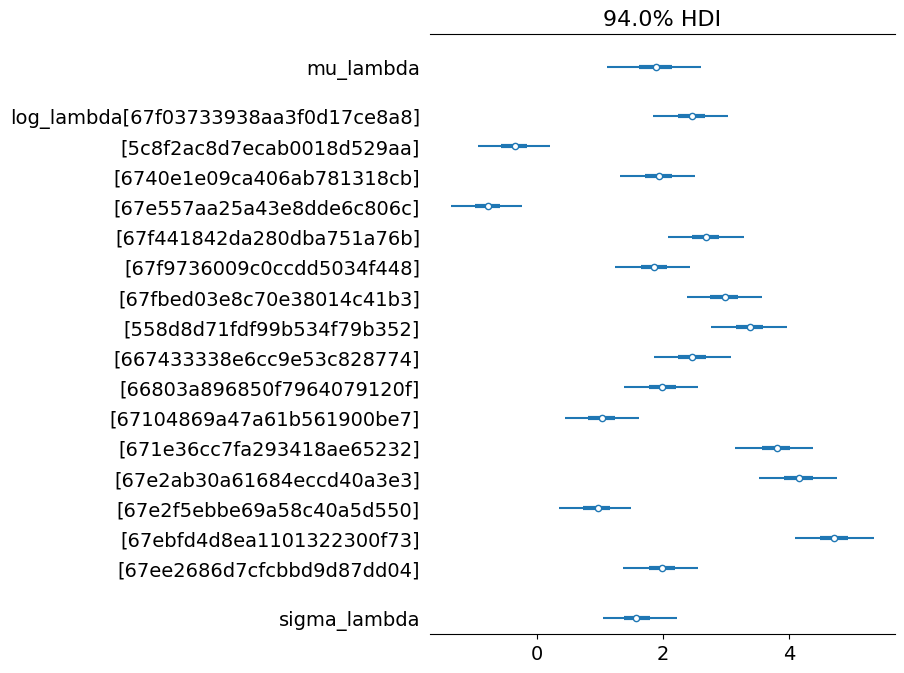

In [34]:
az.plot_forest(task4_exp_idata, combined=True)

In [39]:
# posterior predictive checks 
with task4_exp:
    pm.sample_posterior_predictive(task4_exp_idata, extend_inferencedata=True)
    pm.compute_log_likelihood(task4_exp_idata)

Sampling: [error]


Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:007m━━━━━━━━━━━━  69% 0:00:01 / 0:00:00
Computing ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00m━━━━━━━━━━━━  69% 0:00:01


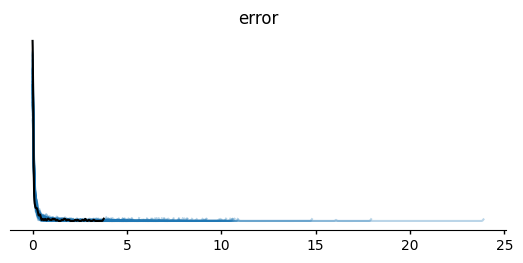

In [36]:
azp.plot_ppc_dist(task4_exp_idata)

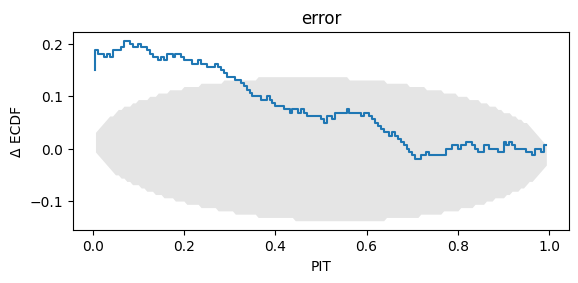

In [38]:
azp.plot_ppc_pit(task4_exp_idata)

The above tells us that the fit is not quite good ... 
We save the fitted model nonetheless ... 

In [40]:
# save fitted model 
task4_exp_idata.to_netcdf("../fitted_models/task4.exp.nc")

'../fitted_models/task4.exp.nc'

## Lomax model 

Here's the math model: 
... 

Hmm there is no native implementation of the lomax model ... 

Skipping for now ... 


In [41]:
# TODO 

## Weibull distribution 

[PyMC Source](https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.Weibull.html) --- alpha is the shape parameter and beta is the scale parameter ... 

[Wikipedia](https://en.wikipedia.org/wiki/Weibull_distribution) refers to shape as $k$ and scale as $\lambda$.

Math model: 

$$
\begin{align*}
\text{error}_i &\sim \text{Weibull}(\lambda_{\text{PID}[i]}, k_{\text{PID}[i]}) \\ 
\log(\lambda_j) &\sim \mathcal{N}(\mu_\lambda, \sigma_\lambda ) \\ 
\log(k_j) &\sim \mathcal{N}(\mu_k, \sigma_k) \\ 
\mu_\lambda, \mu_k &\sim \mathcal{N}(0, 1) \\ 
\sigma_\lambda, \sigma_k &\sim \text{HalfCauchy}(0, 1)
\end{align*}
$$

In [64]:
with pm.Model(coords = {
    "participant": unq_pids
}) as task4_weibull: 
    # hyperpriors 
    sigma_lambda = pm.HalfCauchy("sigma_lambda", 1)
    sigma_k = pm.HalfCauchy("sigma_k", 1)
    mu_lambda = pm.Normal("mu_lambda", 0, 1)
    mu_k = pm.Normal("mu_k", 0, 1)
    # priors 
    log_lambda = pm.Normal("log_lambda", mu_lambda, sigma_lambda, dims="participant")
    p_lambda = pm.math.exp(log_lambda[participant_idx])
    log_k = pm.Normal("log_k", mu_k, sigma_k, dims="participant")
    k = pm.math.exp(log_k[participant_idx])

    error = pm.Weibull("error", alpha=k, beta=p_lambda, observed=obv_error + 1e-6)

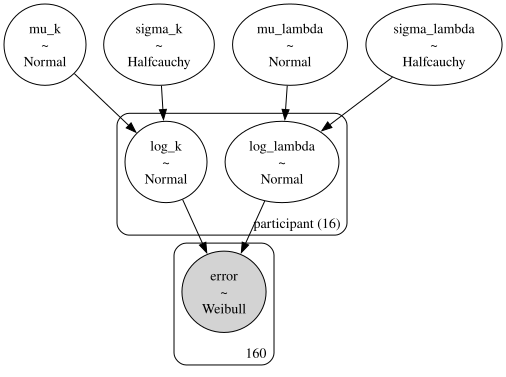

In [65]:
pm.model_to_graphviz(task4_weibull)

In [66]:
# fit the model 

with task4_weibull:
    task4_weibull_idata = pm.sample(
        draws=3000,
        tune=3000,
        chains=4,
        cores=4,
        # target_accept=0.95,
        random_seed = 42, 
        progressbar=False
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_lambda, sigma_k, mu_lambda, mu_k, log_lambda, log_k]
Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 2 seconds.


Note that we added `1e-6` to make the model fit. 

In [67]:
az.summary(task4_weibull_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_lambda,-2.097,0.472,-2.997,-1.232,0.005,0.005,8505.0,7423.0,1.0
mu_k,-0.617,0.165,-0.914,-0.293,0.002,0.002,7908.0,8128.0,1.0
log_lambda[67f03733938aa3f0d17ce8a8],-2.807,0.758,-4.216,-1.316,0.007,0.009,12569.0,7378.0,1.0
log_lambda[5c8f2ac8d7ecab0018d529aa],0.467,0.233,0.037,0.903,0.003,0.004,8611.0,5254.0,1.0
log_lambda[6740e1e09ca406ab781318cb],-2.465,0.779,-3.960,-1.020,0.008,0.009,9018.0,7078.0,1.0
log_lambda[67e557aa25a43e8dde6c806c],0.900,0.199,0.496,1.253,0.002,0.003,7928.0,4875.0,1.0
log_lambda[67f441842da280dba751a76b],-3.128,0.799,-4.609,-1.589,0.008,0.009,11362.0,8458.0,1.0
log_lambda[67f9736009c0ccdd5034f448],-2.447,0.728,-3.828,-1.073,0.007,0.008,10394.0,7662.0,1.0
log_lambda[67fbed03e8c70e38014c41b3],-3.303,0.664,-4.536,-2.023,0.007,0.007,10198.0,7946.0,1.0
log_lambda[558d8d71fdf99b534f79b352],-3.601,0.601,-4.720,-2.455,0.006,0.007,11003.0,6667.0,1.0


array([[<Axes: title={'center': 'mu_lambda'}>, <Axes: title={'center': 'mu_lambda'}>],
       [<Axes: title={'center': 'mu_k'}>, <Axes: title={'center': 'mu_k'}>],
       [<Axes: title={'center': 'log_lambda'}>, <Axes: title={'center': 'log_lambda'}>],
       [<Axes: title={'center': 'log_k'}>, <Axes: title={'center': 'log_k'}>],
       [<Axes: title={'center': 'sigma_lambda'}>, <Axes: title={'center': 'sigma_lambda'}>],
       [<Axes: title={'center': 'sigma_k'}>, <Axes: title={'center': 'sigma_k'}>]], dtype=object)

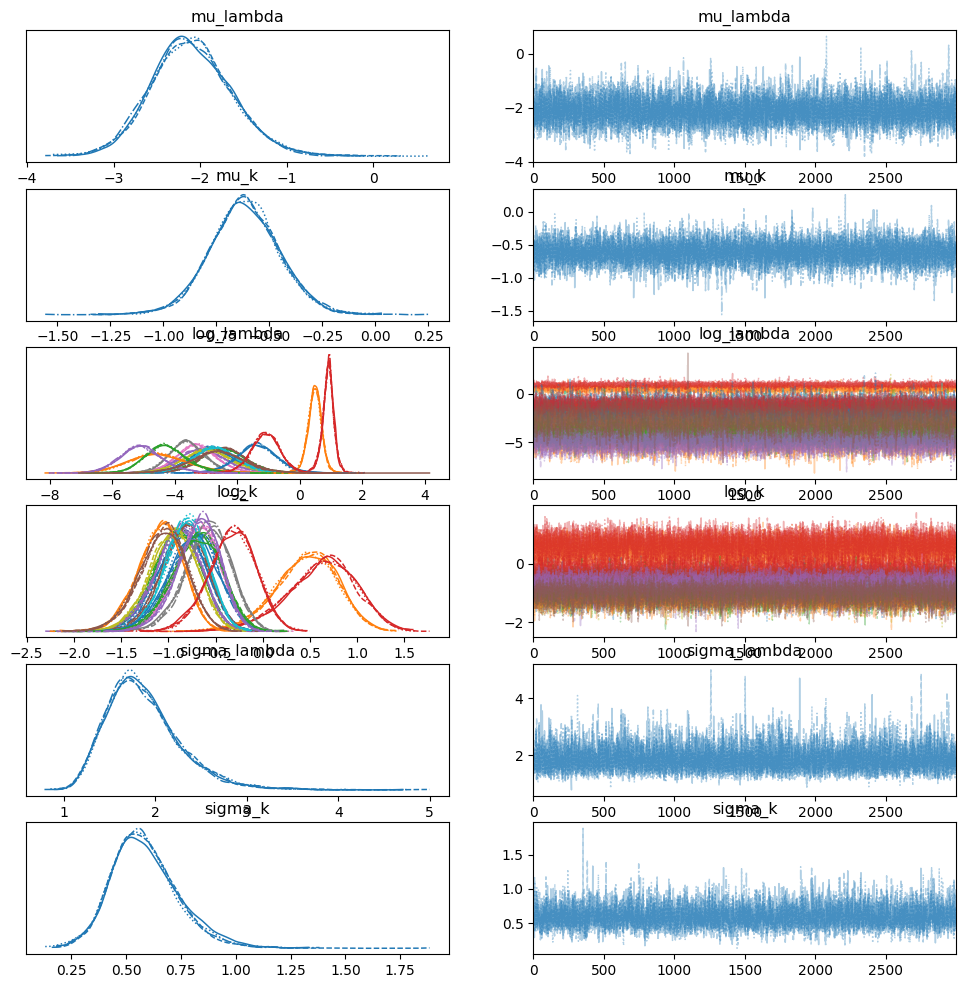

In [69]:
az.plot_trace(task4_weibull_idata)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

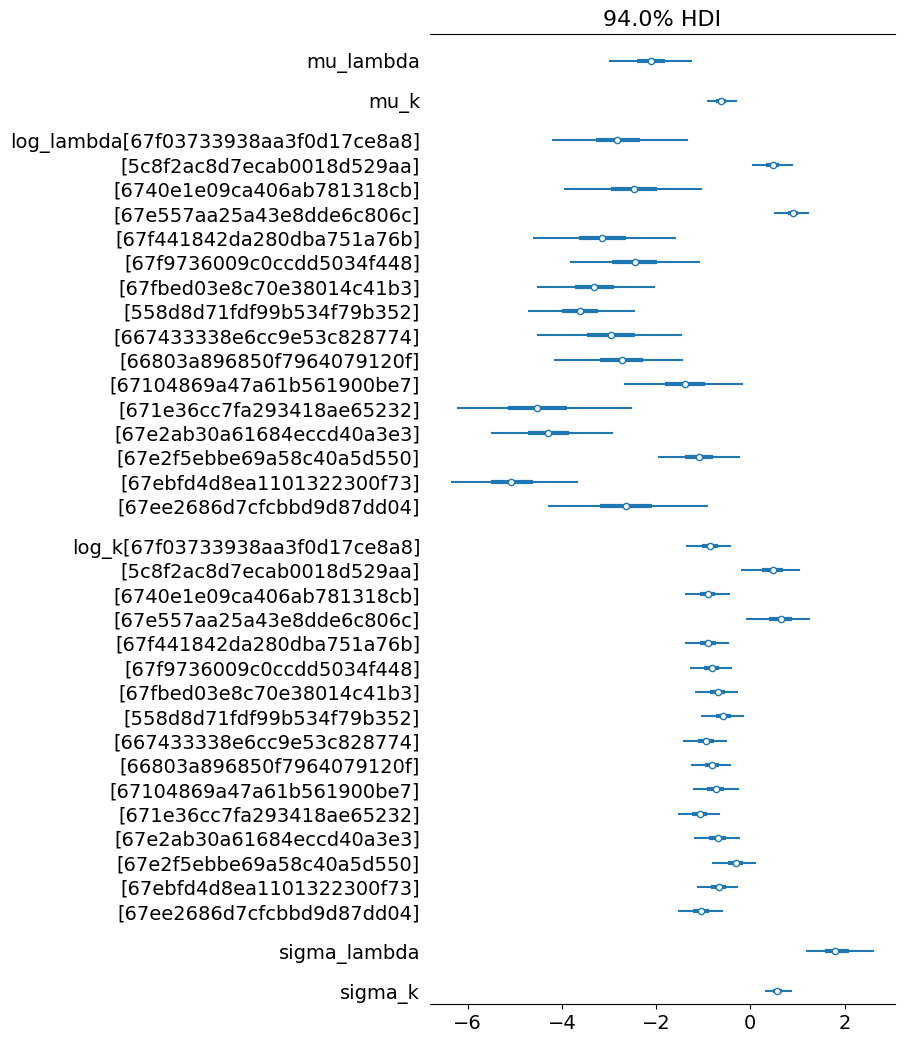

In [71]:
az.plot_forest(task4_weibull_idata, combined=True)

In [72]:
# posterior predictive check 
with task4_weibull:
    pm.sample_posterior_predictive(task4_weibull_idata, extend_inferencedata=True)
    pm.compute_log_likelihood(task4_weibull_idata)

Sampling: [error]


Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:008;5;237m━━━━━━  84% 0:00:01 / 0:00:00
Computing ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00━━━━━━━━━━━━━  67% 0:00:01


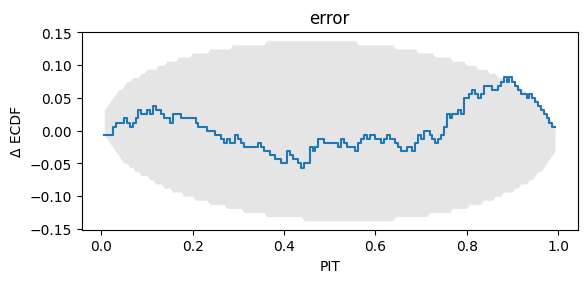

In [73]:
azp.plot_ppc_pit(task4_weibull_idata)

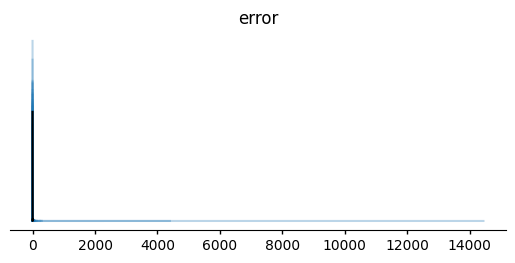

In [74]:
azp.plot_ppc_dist(task4_weibull_idata)

In [ ]:
# save fitted data 
task4_weibull_idata.to_netcdf()

## Log-Normal distribution 

Math equation: 
$$
\begin{align*}
\text{error}_i &\sim \text{LogNormal}(\mu_{\text{PID}[i]}, \sigma_{\text{PID}[i]}) \\ 
\mu_j &\sim \mathcal{N}(\bar{\mu}, \tau_\mu) \\ 
\log(\sigma_j) &\sim \mathcal{N}(\bar{\sigma}, \tau_\sigma) \\ 
\bar{\mu}, \bar{\sigma} &\sim \mathcal{N}(0, 1) \\ 
\tau_\mu, \tau_\sigma &\sim \text{HalfCauchy}(0, 1)
\end{align*}
$$

In [52]:
with pm.Model(coords={
    "participant": unq_pids
}) as task4_logNorm:
    # hyperpriors 
    tau_mu = pm.HalfCauchy("tau_mu", 1)
    tau_sigma = pm.HalfCauchy("tau_sigma", 1)
    mu_bar = pm.Normal("mu_bar", 0, 1)
    sigma_bar = pm.Normal("sigma_bar", 0, 1)
    # priors 
    mu = pm.Normal("mu", mu_bar, tau_mu, dims="participant")
    log_sigma = pm.Normal("log_sigma", sigma_bar, tau_sigma, dims="participant")
    sigma = pm.math.exp(log_sigma[participant_idx])

    error = pm.LogNormal("error", mu[participant_idx], sigma, observed=obv_error)

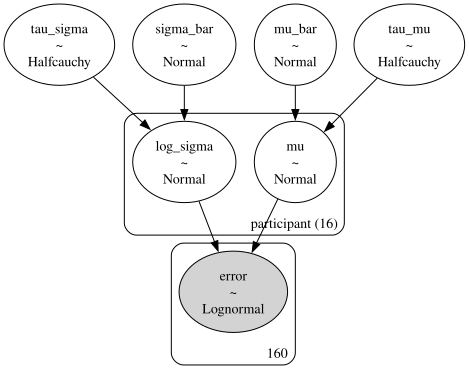

In [53]:
pm.model_to_graphviz(task4_logNorm)

In [54]:
# fit the model 
with task4_logNorm:
    task4_logNorm_idata = pm.sample(
        draws=3000,
        tune=3000,
        chains=4,
        cores=4,
        # target_accept=0.95,
        random_seed = 42, 
        progressbar=False
    )

Initializing NUTS using jitter+adapt_diag...


SamplingError: Initial evaluation of model at starting point failed!
Starting values:
{'tau_mu_log__': array(-0.43686639), 'tau_sigma_log__': array(-0.17764445), 'mu_bar': array(-0.53257793), 'sigma_bar': array(-0.31962516), 'mu': array([-0.19682291, -1.49565159, -0.71710314, -0.01949935, -0.17159654, -1.25419195, -0.39665983, -1.02040683, -0.61891534, -0.34377481, -1.17615777,  0.12985353,  0.21500502, -0.90188285,  0.07459377,
       -1.240504  ]), 'log_sigma': array([ 0.52894179,  0.09171123, -0.21313147, -0.52434875, -1.15690863,  0.37013089,  0.63118915, -0.63769534, -0.18252714, -1.30369605, -1.01000373, -0.43953317, -0.67897571,  0.08925779, -1.05225593,
       -0.27367201])}

Logp initial evaluation results:
{'tau_mu': np.float64(-1.24), 'tau_sigma': np.float64(-1.16), 'mu_bar': np.float64(-1.06), 'sigma_bar': np.float64(-0.97), 'mu': np.float64(-13.35), 'log_sigma': np.float64(-15.74), 'error': np.float64(-inf)}
You can call `model.debug()` for more details.

In [56]:
task4_logNorm.debug(verbose=True)

point={'tau_mu_log__': array(0.), 'tau_sigma_log__': array(0.), 'mu_bar': array(0.), 'sigma_bar': array(0.), 'mu': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'log_sigma': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])}

The variable error has the following parameters:
0: AdvancedSubtensor1 [id A] <Vector(float64, shape=(160,))>
 ├─ mu [id B] <Vector(float64, shape=(?,))>
 └─ [ 0  0  0 ... 15 15 15] [id C] <Vector(int64, shape=(160,))>
1: Exp [id D] <Vector(float64, shape=(160,))>
 └─ AdvancedSubtensor1 [id E] <Vector(float64, shape=(160,))>
    ├─ log_sigma [id F] <Vector(float64, shape=(?,))>
    └─ [ 0  0  0 ... 15 15 15] [id C] <Vector(int64, shape=(160,))>
The parameters evaluate to:
0: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 